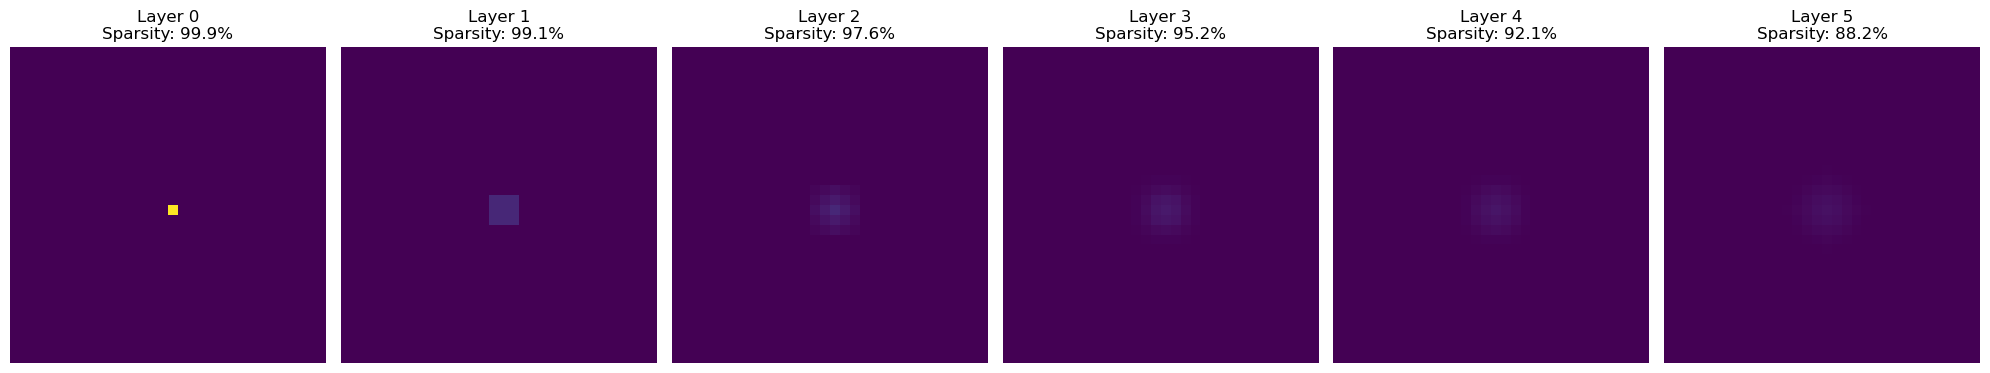

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

def visualize_dilution(num_layers=5):
    # 1. Initialize a 32x32 sparse "image" with a single pixel at center
    size = 32
    img = torch.zeros((1, 1, size, size))
    img[0, 0, size // 2, size // 2] = 1.0
    
    # Define a standard 3x3 convolution
    # We use weights of 1/9 (average pooling effect) to simulate signal spreading
    conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
    with torch.no_grad():
        conv.weight.fill_(1.0 / 9.0)

    # Setup plotting
    fig, axes = plt.subplots(1, num_layers + 1, figsize=(20, 4))
    
    current_feat = img
    for i in range(num_layers + 1):
        # Calculate Sparsity: (Number of zeros) / (Total pixels)
        sparsity = (current_feat == 0).sum().item() / current_feat.numel() * 100
        
        # Plotting
        ax = axes[i]
        im = ax.imshow(current_feat.detach().numpy()[0][0], vmin=0, vmax=img.max())
        ax.set_title(f"Layer {i}\nSparsity: {sparsity:.1f}%")
        ax.axis('off')
        
        # Apply convolution for the next iteration
        if i < num_layers:
            current_feat = conv(current_feat)
            # Clip very small values to zero to simulate "true" sparsity
            current_feat[current_feat < 1e-5] = 0

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_dilution(num_layers=5)

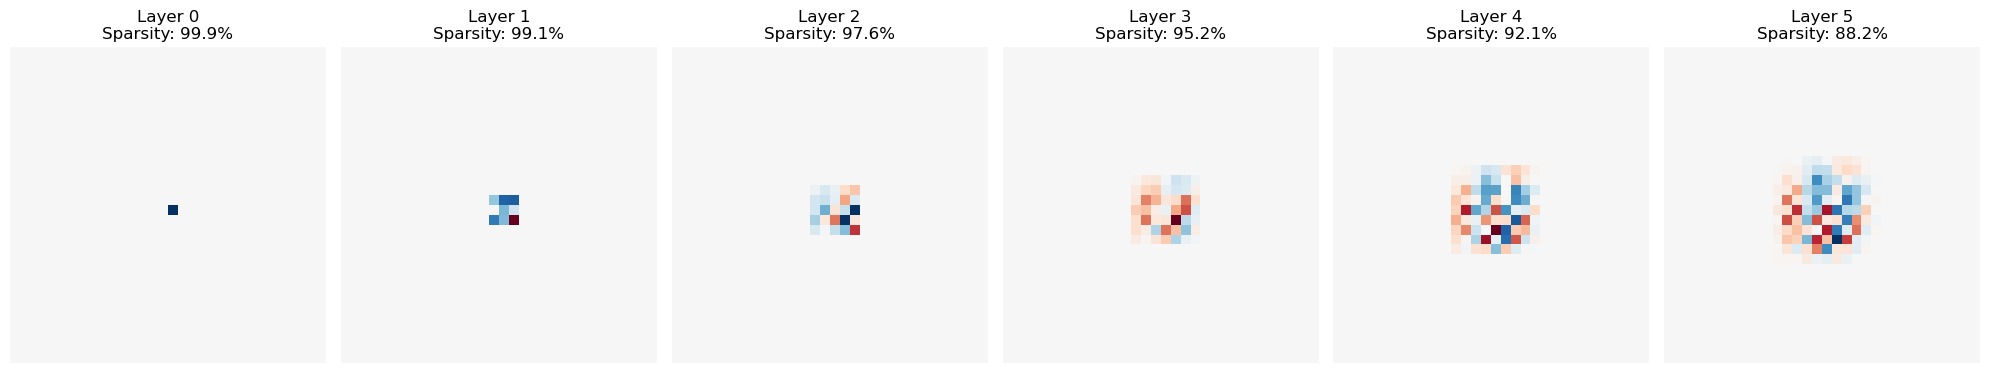

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_dilution(num_layers=5):
    # 1. Initialize a 32x32 sparse "image" with a single pixel at center
    size = 32
    img = torch.zeros((1, 1, size, size))
    img[0, 0, size // 2, size // 2] = 1.0
    
    # 2. Define a standard 3x3 convolution
    # We'll use Kaiming Normal initialization to get realistic random weights
    conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
    nn.init.kaiming_normal_(conv.weight)

    # Setup plotting
    fig, axes = plt.subplots(1, num_layers + 1, figsize=(20, 4))
    
    current_feat = img
    for i in range(num_layers + 1):
        # Calculate Sparsity: (Number of zeros) / (Total pixels)
        sparsity = (current_feat == 0).sum().item() / current_feat.numel() * 100
        
        # Plotting
        ax = axes[i]
        # Calculate dynamic range for the current layer to keep the signal visible
        v_limit = float(current_feat.abs().max()) if current_feat.abs().max() > 0 else 1.0
        
        im = ax.imshow(
            current_feat.detach().numpy()[0][0], 
            cmap='RdBu', 
            vmin=-v_limit, 
            vmax=v_limit
        )
        ax.set_title(f"Layer {i}\nSparsity: {sparsity:.1f}%")
        ax.axis('off')
        
        # Apply convolution for the next iteration
        if i < num_layers:
            # We use a new random weight set at each layer to simulate a deep network
            nn.init.kaiming_normal_(conv.weight)
            current_feat = conv(current_feat)
            
            # Small epsilon to maintain "true" sparsity for visualization
            current_feat[current_feat.abs() < 1e-5] = 0

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_random_dilution(num_layers=5)